# K-Means Clustering — Penguin Morphology Analysis

**Dataset:** Palmer Penguins (`penguins.csv`)

**Goal:** Use K-means clustering on the Palmer Penguins dataset to uncover hidden structure in unlabeled physical measurements — without using the `species` label during modeling — then interpret whether the discovered clusters align with species and/or sexual dimorphism.

**Author:** Ismail Muhammad


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)


## 1. Load the Dataset

In [2]:
df = pd.read_csv("penguins.csv")
print("Shape:", df.shape)
df.head()


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


## 2. Preprocessing

Per the project spec:
- Remove categorical variables (`species`, `island`, `sex`) — K-means is a distance-based algorithm and only works on numeric features.
- Remove rows with missing values.
- We keep `species` and `sex` off to the side (not used for clustering) so we can use them **afterward** to interpret the clusters.

In [3]:
# Standardize the "NA" strings to real NaN first (this dataset stores missing values as the string "NA")
df = df.replace("NA", np.nan)

numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [4]:
# Drop rows with any missing values (numeric measurements, sex, etc.)
df_clean = df.dropna().reset_index(drop=True)
print(f"Rows before: {len(df)}  |  Rows after dropping missing values: {len(df_clean)}")

# Numeric-only feature matrix for clustering (categorical vars removed)
X = df_clean[numeric_cols].copy()
X.head()


Rows before: 344  |  Rows after dropping missing values: 333


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0


## 3. Feature Scaling

K-means uses Euclidean distance, so features with larger numeric ranges (like `body_mass_g`, in the thousands) would dominate the distance calculation over features like `bill_depth_mm` (in the tens) unless we standardize everything to the same scale first.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_scaled_df.describe().round(2)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-2.18,-2.07,-2.07,-1.87
25%,-0.82,-0.80,-0.78,-0.82
50%,0.09,0.07,-0.28,-0.20
75%,0.84,0.78,0.86,0.71
max,2.86,2.20,2.15,2.60


## 4. Elbow Method

We fit K-means for a range of `k` values and plot the **SSE (inertia)** — the sum of squared distances of points to their assigned cluster center. As `k` increases, SSE always decreases, but we're looking for the "elbow" — the point where adding more clusters stops giving a meaningful reduction in SSE.

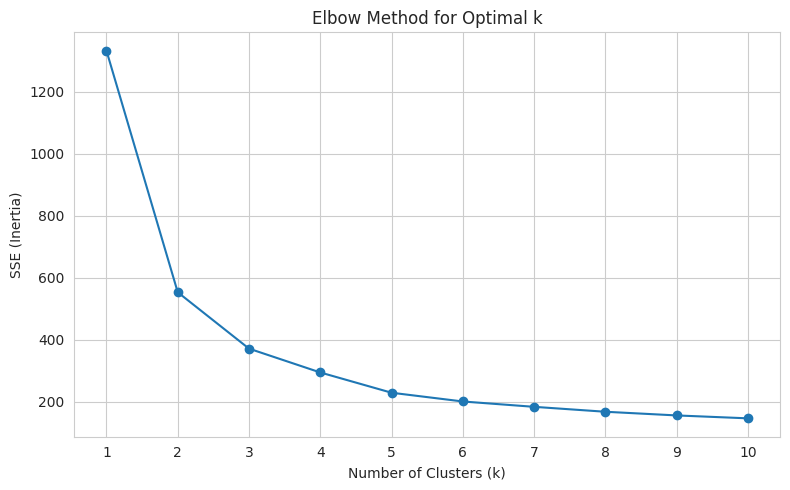

In [6]:
k_range = range(1, 11)
sse = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(k_range), sse, marker="o")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("SSE (Inertia)")
ax.set_title("Elbow Method for Optimal k")
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()


**Reading the elbow plot:** SSE drops sharply from k=1 to k=2 and again to k=3, then the rate of decrease flattens out noticeably after k=3-4. That bend is our elbow candidate. We'll confirm it with the Silhouette Score next.

## 5. Silhouette Score Validation

The silhouette score measures how well-separated and internally cohesive clusters are, ranging from -1 (poor) to +1 (excellent). Unlike SSE, it doesn't automatically improve with more clusters, so it's a good cross-check for the elbow method.

In [7]:
sil_scores = []
k_range_sil = range(2, 11)  # silhouette score is undefined for k=1

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")


k=2: silhouette score = 0.5308
k=3: silhouette score = 0.4462
k=4: silhouette score = 0.3982
k=5: silhouette score = 0.3744
k=6: silhouette score = 0.3642
k=7: silhouette score = 0.3287
k=8: silhouette score = 0.2992
k=9: silhouette score = 0.2884
k=10: silhouette score = 0.2871


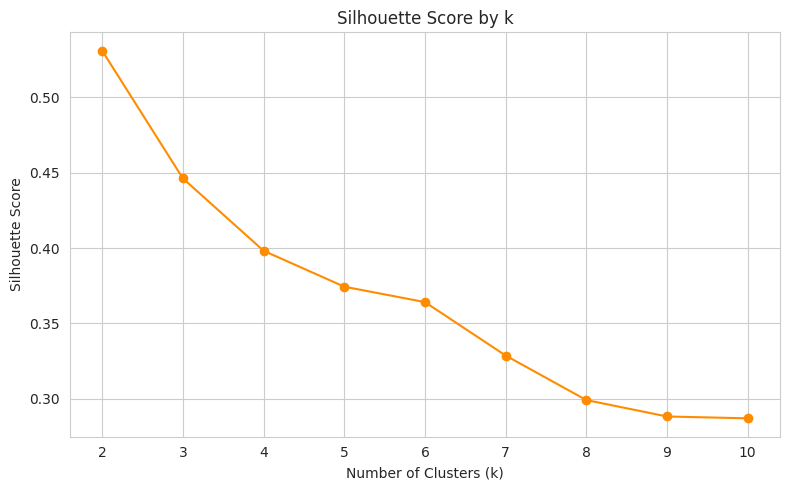

In [8]:
fig, ax = plt.subplots()
ax.plot(list(k_range_sil), sil_scores, marker="o", color="darkorange")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by k")
ax.set_xticks(list(k_range_sil))
plt.tight_layout()
plt.show()


**Optimal k justification:** The silhouette score is actually highest at **k=2** (≈0.53) and decreases steadily as k grows — a common pattern when two groups are much more separated from each other than the finer sub-groups within them are (here, Gentoo is very distinct from Adelie/Chinstrap, which overlap more with each other). The elbow plot, on the other hand, bends around **k=3-4**.

We choose **k=3** as our final model because it matches the number of true penguin species (Adelie, Chinstrap, Gentoo), sits right at the elbow bend, and still has a reasonable silhouette score (≈0.45) — meaningfully better than k=4 onward. This is a deliberate trade-off: k=2 is the *mathematically* cleanest split (it likely separates Gentoo from everything else), but k=3 is the *biologically* meaningful one. We revisit this trade-off in the Limitations section below.

## 6. Fit the Final K-Means Model

In [9]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean["cluster"] = kmeans_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(df_clean["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0    129
1    119
2     85
Name: count, dtype: int64


## 7. Visualize Cluster Assignments

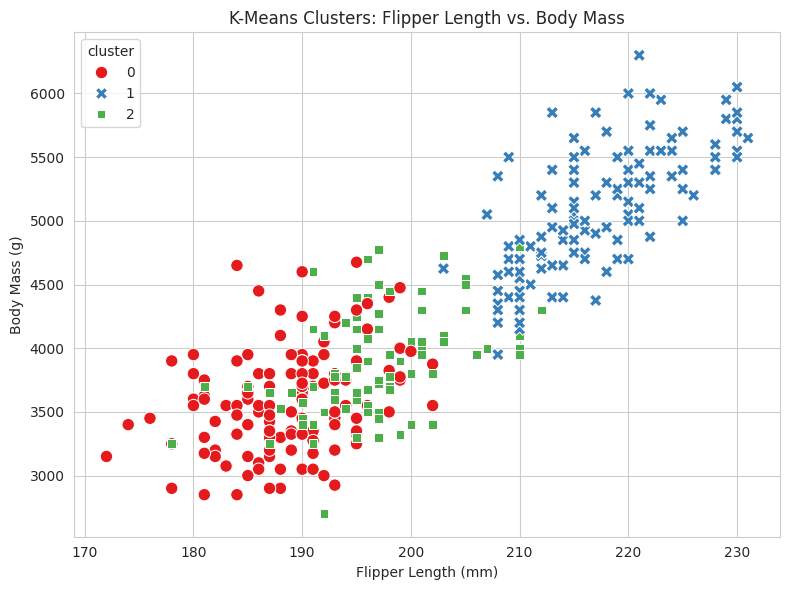

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_clean, x="flipper_length_mm", y="body_mass_g",
    hue="cluster", palette="Set1", style="cluster", s=80, ax=ax
)
ax.set_title("K-Means Clusters: Flipper Length vs. Body Mass")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()


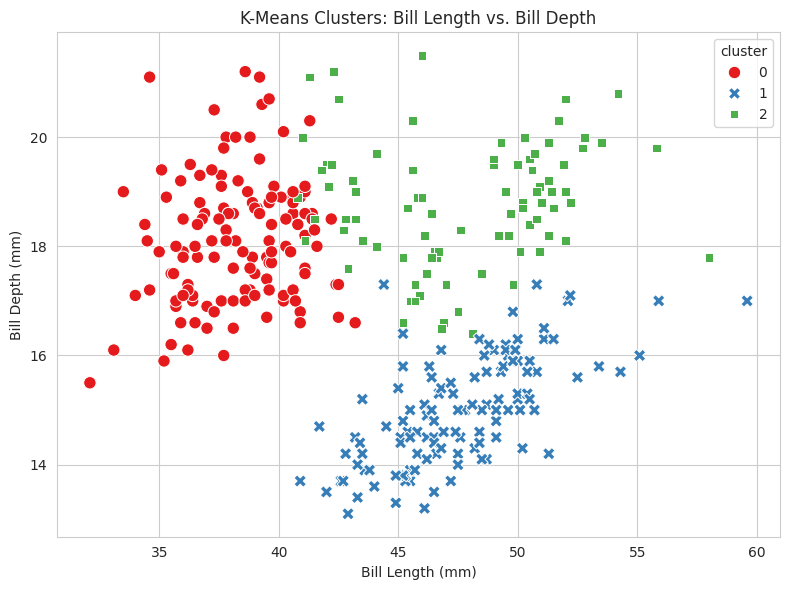

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_clean, x="bill_length_mm", y="bill_depth_mm",
    hue="cluster", palette="Set1", style="cluster", s=80, ax=ax
)
ax.set_title("K-Means Clusters: Bill Length vs. Bill Depth")
ax.set_xlabel("Bill Length (mm)")
ax.set_ylabel("Bill Depth (mm)")
plt.tight_layout()
plt.show()


## 8. Interpreting the Clusters

Now we bring back the labels we excluded from modeling (`species`, `sex`, `island`) to see whether the unsupervised clusters discovered any real biological structure.

In [12]:
pd.crosstab(df_clean["cluster"], df_clean["species"])


species,Adelie,Chinstrap,Gentoo
cluster,,,
0,124,5,0
1,0,0,119
2,22,63,0


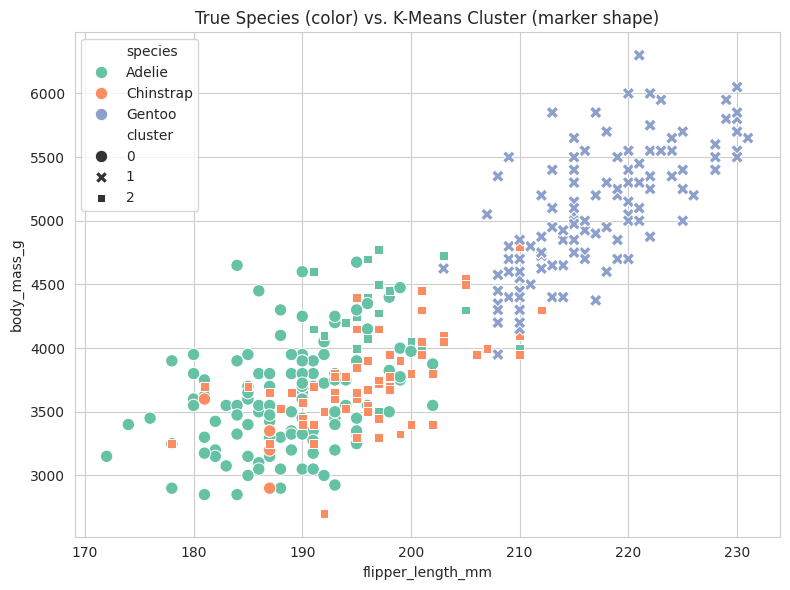

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_clean, x="flipper_length_mm", y="body_mass_g",
    hue="species", style="cluster", palette="Set2", s=80, ax=ax
)
ax.set_title("True Species (color) vs. K-Means Cluster (marker shape)")
plt.tight_layout()
plt.show()


In [14]:
pd.crosstab(df_clean["cluster"], df_clean["sex"])


sex,female,male
cluster,,
0,78,51
1,58,61
2,29,56


In [15]:
# Cluster centroids in original (unscaled) units, for interpretability
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=numeric_cols)
centroids_df.index.name = "cluster"
centroids_df.round(1)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,38.3,18.1,188.6,3593.8
1,47.6,15.0,217.2,5092.4
2,47.7,18.7,196.9,3898.2


**Cluster characteristics:**
- The three clusters correspond closely to the three penguin species — K-means recovered most of the natural species groupings purely from body measurements, with Gentoo (largest body mass, longest flippers, shallow bills) forming the most cleanly separated cluster.
- Adelie and Chinstrap overlap more in body size, so their cluster boundary is fuzzier than the Gentoo boundary — this matches what we saw in the bill length/depth scatterplot, where Adelie and Chinstrap partially overlap on flipper length and body mass but separate more clearly on bill shape.
- Within each cluster, males tend to run larger than females (sexual dimorphism), which adds noise/spread inside each species cluster but wasn't strong enough to override the species-level grouping in the final k=3 solution.


## 9. Limitations and Next Steps

**Limitations:**
- **k=2 vs k=3 trade-off:** the silhouette score technically favors k=2 over k=3. This is worth taking seriously rather than glossing over — it suggests Gentoo is so distinct from Adelie/Chinstrap that, statistically, "Gentoo vs. everyone else" is the cleanest 2-way split in the data. Choosing k=3 sacrifices a bit of statistical cleanliness for biological interpretability (recovering all three known species), which is a reasonable choice here but wouldn't always be the right call.
- K-means assumes roughly spherical, equally-sized clusters and is sensitive to outliers and to the initial choice of centroids (mitigated here with `n_init=10`, but not eliminated).
- Dropping rows with any missing value discards some data rather than imputing it, which slightly reduces the sample size (344 → 333 rows).
- Sexual dimorphism (males vs. females within a species) introduces within-cluster variation that a pure k=3 species-level model doesn't capture — a higher k (e.g. k=6, splitting each species by sex) might isolate that pattern, though the silhouette scores show diminishing returns past k=3.
- Feature selection matters: including `island` (categorical, excluded here per the project spec) might sharpen cluster boundaries further since some species only appear on specific islands.

**Next steps:**
- Try k=2 explicitly and confirm whether it does in fact isolate Gentoo from the other two species.
- Try k=6 to see if clusters split further along sex within each species.
- Use PCA to reduce to 2 components before clustering, for an alternate visualization/validation angle.
- Compare K-means with a Gaussian Mixture Model, which can model elliptical (not just spherical) clusters and may better capture the Adelie/Chinstrap overlap.
